In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

# Load Data

In [22]:
df = pd.read_excel('luad_tcga_clinical_data.xlsx')
df.head()

,Patient ID,Diagnosis Age,Neoplasm Disease Stage American Joint Committee on Cancer Code,Mutation Count,Overall Survival (Months),Overall Survival Status,Sex,Person Cigarette Smoking History Pack Year Value
0,TCGA-05-4244,70.0,Stage IV,NaN,0.00,0:LIVING,MALE,38.0
1,TCGA-05-4245,81.0,Stage IIIA,NaN,23.98,0:LIVING,Male,32.0
2,TCGA-05-4249,67.0,Stage IB,289.0,50.03,0:LIVING,Male,52.0
3,TCGA-05-4250,79.0,Stage IIIA,NaN,3.98,1:DECEASED,Female,47.0
4,TCGA-05-4382,68.0,Stage IB,1272.0,19.94,0:LIVING,Male,62.0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 586 entries, 0 to 585
Data columns (total 8 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   Patient ID                                                      586 non-null    object 
 1   Diagnosis Age                                                   505 non-null    float64
 2   Neoplasm Disease Stage American Joint Committee on Cancer Code  516 non-null    object 
 3   Mutation Count                                                  230 non-null    float64
 4   Overall Survival (Months)                                       515 non-null    float64
 5   Overall Survival Status                                         524 non-null    object 
 6   Sex                                                             524 non-null    object 
 7   Person Cigarette Smoking History Pack Year Value      

# Cleaning Data

In [24]:
# --- CLEANING: Event Status ---
# Mengubah format teks aneh "1:DECEASED" menjadi integer (1=Event, 0=Censored)
def parse_status(val):
    s = str(val).upper()
    if 'DECEASED' in s or '1' in s and ':' in s: return 1
    if 'LIVING' in s or '0' in s and ':' in s: return 0
    return np.nan

# Membuat kolom baru 'event' tanpa membuang kolom asli 'Overall Survival Status'
df['event'] = df['Overall Survival Status'].apply(parse_status)

In [25]:
# --- CLEANING: Time ---
# Paksa ke numerik, error jadi NaN
df['time'] = pd.to_numeric(df['Overall Survival (Months)'], errors='coerce')

In [26]:
#--- CLEANING: Stage (Penyederhanaan) ---
# Menggabungkan Stage IA, IB -> Stage I agar statistik lebih kuat
def simplify_stage(val):
    s = str(val).upper()
    if 'IV' in s: return 4
    if 'III' in s: return 3
    if 'II' in s: return 2
    if 'I' in s: return 1
    return np.nan

# Kolom asli: 'Neoplasm Disease Stage American Joint Committee on Cancer Code'
df['stage'] = df['Neoplasm Disease Stage American Joint Committee on Cancer Code'].apply(simplify_stage)

In [27]:
# --- CLEANING: Sex ---
# Mapping ke biner (Male=1, Female=0 adalah konvensi umum, tapi bebas asal konsisten)
df['sex_code'] = df['Sex'].str.lower().map({'male': 1, 'female': 0})

In [28]:
# --- CLEANING: Pack Years & Age ---
# Kolom asli: 'Age', 'Person Cigarette Smoking History Pack Year Value'
df['age_clean'] = pd.to_numeric(df['Diagnosis Age'], errors='coerce')
df['pack_years'] = pd.to_numeric(df['Person Cigarette Smoking History Pack Year Value'], errors='coerce')

In [29]:
# Imputasi Median untuk variabel kontinu (Rokok & Umur)
df['pack_years'] = df['pack_years'].fillna(df['pack_years'].median())
df['age_clean'] = df['age_clean'].fillna(df['age_clean'].median())

In [30]:
# Drop baris HANYA jika target analisis (Time/Event) atau Stratifikasi Utama (Stage) kosong
# Kita tidak membuang kolom, hanya baris yang tidak valid untuk analisis survival
df_clean = df.dropna(subset=['time', 'event', 'stage', 'sex_code'])

In [31]:
df_clean.head()

,Patient ID,Diagnosis Age,Neoplasm Disease Stage American Joint Committee on Cancer Code,Mutation Count,Overall Survival (Months),Overall Survival Status,Sex,Person Cigarette Smoking History Pack Year Value,event,time,stage,sex_code,age_clean,pack_years
0,TCGA-05-4244,70.0,Stage IV,NaN,0.00,0:LIVING,MALE,38.0,0.0,0.00,4.0,1.0,70.0,38.0
1,TCGA-05-4245,81.0,Stage IIIA,NaN,23.98,0:LIVING,Male,32.0,0.0,23.98,3.0,1.0,81.0,32.0
2,TCGA-05-4249,67.0,Stage IB,289.0,50.03,0:LIVING,Male,52.0,0.0,50.03,1.0,1.0,67.0,52.0
3,TCGA-05-4250,79.0,Stage IIIA,NaN,3.98,1:DECEASED,Female,47.0,1.0,3.98,3.0,0.0,79.0,47.0
4,TCGA-05-4382,68.0,Stage IB,1272.0,19.94,0:LIVING,Male,62.0,0.0,19.94,1.0,1.0,68.0,62.0


In [ ]:
print(f"Jumlah sampel awal: {len(df)}")
print(f"Jumlah sampel bersih siap analisis: {len(df_clean)}")
print("-" * 30)

Jumlah sampel awal: 586
Jumlah sampel bersih siap analisis: 507
------------------------------


# EDA

Text(0.5, 0, 'Bulan')

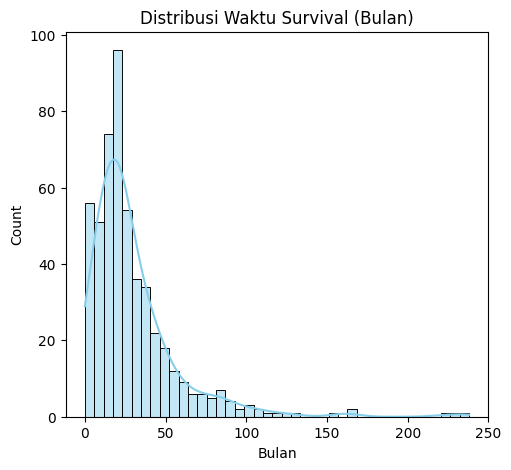

In [32]:
plt.figure(figsize=(12, 5))

# Distribusi Waktu Survival
plt.subplot(1, 2, 1)
sns.histplot(df_clean['time'], kde=True, color='skyblue')
plt.title('Distribusi Waktu Survival (Bulan)')
plt.xlabel('Bulan')

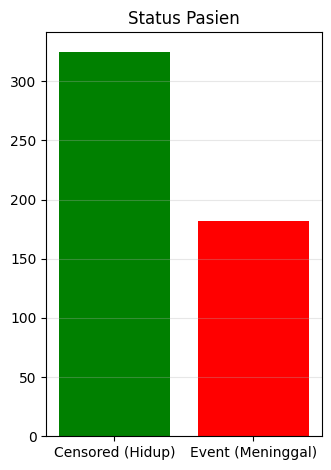

In [33]:
# Distribusi Kejadian (Hidup vs Meninggal)
plt.subplot(1, 2, 2)
event_counts = df_clean['event'].value_counts()
plt.bar(['Censored (Hidup)', 'Event (Meninggal)'], event_counts.values, color=['green', 'red'])
plt.title('Status Pasien')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Rename kolom agar coding lebih mudah
df = df.rename(columns={
    'Overall Survival (Months)': 'time',
    'Overall Survival Status': 'status_raw',
    'Diagnosis Age': 'Age',
    'Neoplasm Disease Stage American Joint Committee on Cancer Code': 'stage',
    'Person Cigarette Smoking History Pack Year Value': 'pack_years',
    'Mutation Count': 'mutations'
})

# Parsing Status Kejadian (Event)
# Mengubah "1:DECEASED" -> 1, "0:LIVING" -> 0
df['event'] = df['status_raw'].apply(lambda x: 1 if 'DECEASED' in str(x).upper() else 0)

# Membersihkan Stage (Simplifikasi)
# Mengambil kata kedua "Stage IIIA" -> "IIIA", lalu ambil huruf awalnya saja jika mau grouping kasar
df['stage_group'] = df['stage'].str.extract(r'(I+|IV)').fillna('Unknown')

# Membersihkan Sex
df['gender'] = df['Sex'].map({'Male': 1, 'MALE': 1, 'Female': 0, 'FEMALE': 0})

# Menangani Missing Values (Drop NA di Time/Event, Impute di Kovariat)
df = df.dropna(subset=['time', 'event']) # Tidak bisa analisis tanpa waktu
df['pack_years'] = df['pack_years'].fillna(df['pack_years'].median()) # Imputasi median
df['mutations'] = df['mutations'].fillna(0) # Asumsi tidak ada data = 0 mutasi (atau gunakan median)

# Final Dataset untuk Analisis
df_final = df[['time', 'event', 'Age', 'gender', 'stage_group', 'pack_years', 'mutations']].dropna()

print("Data siap analisis:")
print(df_final.head())

Data siap analisis:
    time  event   Age  gender stage_group  pack_years  mutations
0   0.00      0  70.0       1           I        38.0        0.0
1  23.98      0  81.0       1         III        32.0        0.0
2  50.03      0  67.0       1           I        52.0      289.0
3   3.98      1  79.0       0         III        47.0        0.0
4  19.94      0  68.0       1           I        62.0     1272.0
